# Dormant-pruning shoot analysis of pear trees — minimal Colab reproduction

**Paper:** Jiaqi Li et al., *"Structural parameter determination and pruning pattern analysis of pear tree shoots for dormant pruning"*, **Plant Phenomics** 7(4): 100136 (2025). DOI: [10.1016/j.plaphe.2025.100136](https://doi.org/10.1016/j.plaphe.2025.100136)

**Author code (pinned):** [`Lixiao-bai/Pear_branch_seg_and_analysis`](https://github.com/Lixiao-bai/Pear_branch_seg_and_analysis) @ commit `84e65299d28d9758dff0dfed2ce6a019d724b712` (MIT license).

**What this notebook does (EN):** It runs the paper's core pipeline on **one sample pear tree (`e1-8`)**: it registers the before-pruning (BP) and after-pruning (AP) TLS point clouds, extracts **annual shoots (AS)** and **pruned shoots (PS)** as the non-overlapping regions between the two clouds, clusters them with DBSCAN, and measures each shoot's angle and length from its oriented bounding box (OBB).

**このノートブックの概要（JA）:** 論文の中心パイプラインを**サンプル樹 1 樹（e1-8）**で実行します。剪定前後の TLS 点群を位置合わせし、非重複領域から一年生枝（AS）と剪除枝（PS）を抽出し、DBSCAN でクラスタリング後、OBB から角度と長さを測定します。

## Scope, status and runtime

- **Scope: PARTIAL demonstration** — one tree, one BP/AP pair. This is **not** a reproduction of the paper's dataset-level validation (R² 0.82/0.90/0.92/0.85 over 126 trees; that dataset is available only on request).
- **Execution status: executed on Google Colab (CPU runtime).** No GPU is needed: the method is classical geometry (outlier filtering, ICP, DBSCAN, OBB) with no learned weights.
- **Runtime to select:** `CPU` (Edit → Notebook settings → Hardware accelerator: None). Estimated end-to-end: ~15–30 min including a ~221 MB download.
- **Data:** `data/e1-8_BP.txt` (134,292,917 B) and `data/e1-8_AP.txt` (86,438,882 B) are Git LFS objects pinned to the commit above; SHA-256 is verified after download.

**（JA）** 本ノートブックは部分再現（1 樹のペア点群）です。手法は古典的な幾何処理のため **CPU ランタイムで実行します**。約 221 MB のダウンロードと 15〜30 分を見込んでください。

## 1. Dependencies

The executed path needs only `numpy`, `scipy`, `open3d`, `scikit-learn`, `pandas` and `simpleicp`. The author's `pc-skeletor` is **not** required: in the pinned code the skeleton-based length routine (`cal_length` / `skeletonize_point_cloud`) is commented out and length is measured from the OBB extent instead. `hdbscan` is likewise only an option in comments.

**（JA）** 実行経路に必要な依存のみをインストールします。著者コードでスケルトン化はコメントアウトされているため `pc-skeletor` は不要です。

In [ ]:
get_ipython().system("pip install -q open3d scikit-learn scipy pandas simpleicp")

import numpy, scipy, open3d, sklearn, pandas, simpleicp
print("numpy      ", numpy.__version__)
print("scipy      ", scipy.__version__)
print("open3d     ", open3d.__version__)
print("scikit-learn", sklearn.__version__)
print("pandas     ", pandas.__version__)

numpy       2.1.3
scipy       1.16.3
open3d      0.20.0
scikit-learn 1.6.1
pandas      2.2.3


## 2. Sample data acquisition (pinned, verified)

**（EN）** Downloads the two LFS-hosted sample clouds from the pinned commit and **verifies SHA-256 and byte size** against the Git LFS pointer OIDs recorded in the repository at that commit:
- `data/e1-8_BP.txt` → sha256 `469cdf134e2faf2de35cbeb5a34d159f23164b2751c272b294d5464485f960f3`, 134,292,917 B
- `data/e1-8_AP.txt` → sha256 `6d1e49b65e023739445e7ec33da12a60d8d252aee121d1be614dc3bfeead9465`, 86,438,882 B

**（JA）** サンプル点群（Git LFS オブジェクト）をピン留めしたコミットからダウンロードし、SHA-256 とサイズを検証します。

In [ ]:
import hashlib, urllib.request
from pathlib import Path

COMMIT = "84e65299d28d9758dff0dfed2ce6a019d724b712"
BASE = f"https://media.githubusercontent.com/media/Lixiao-bai/Pear_branch_seg_and_analysis/{COMMIT}/data"
EXPECTED = {  # (sha256, size in bytes) from the Git LFS pointers at the pinned commit
    "e1-8_BP.txt": ("469cdf134e2faf2de35cbeb5a34d159f23164b2751c272b294d5464485f960f3", 134_292_917),
    "e1-8_AP.txt": ("6d1e49b65e023739445e7ec33da12a60d8d252aee121d1be614dc3bfeead9465", 86_438_882),
}
DATA = Path("/content/pear_data"); DATA.mkdir(exist_ok=True)

for name, (want_sha, want_size) in EXPECTED.items():
    dest = DATA / name
    if not dest.exists():
        print("downloading", name, "...")
        urllib.request.urlretrieve(f"{BASE}/{name}", dest)
    size = dest.stat().st_size
    sha = hashlib.sha256(dest.read_bytes()).hexdigest()
    print(name, size, "bytes", sha[:16] + "...")
    assert size == want_size and sha == want_sha, f"verification failed for {name}"
print("All sample files verified.")

downloading e1-8_BP.txt ...


e1-8_BP.txt 134292917 bytes 469cdf134e2faf2d...
downloading e1-8_AP.txt ...


e1-8_AP.txt 86438882 bytes 6d1e49b65e023739...
All sample files verified.


## 3. Load the point clouds

**（EN）** Loads the raw XYZ text clouds exactly like the author's `load_point_cloud` (`np.loadtxt(... )[:, :3]`) and reports basic structure: point counts, spatial extent. Column layout beyond XYZ, if any, is ignored as in the pinned code.

**（JA）** 著者コードと同じ方法で XYZ を読み込み、点数と範囲を確認します。

In [ ]:
import numpy as np

def load_point_cloud(path):
    points = np.loadtxt(path)[:, :3]   # author's Registration.load_point_cloud
    return points

bp = load_point_cloud(DATA / "e1-8_BP.txt")   # before pruning
ap = load_point_cloud(DATA / "e1-8_AP.txt")   # after pruning
for name, pc in [("BP (before pruning)", bp), ("AP (after pruning)", ap)]:
    ext = pc.max(axis=0) - pc.min(axis=0)
    print(f"{name}: {pc.shape[0]:,} points, extent x/y/z = {ext[0]:.2f}/{ext[1]:.2f}/{ext[2]:.2f} m")

BP (before pruning): 2,205,206 points, extent x/y/z = 3.07/3.65/4.08 m
AP (after pruning): 1,442,208 points, extent x/y/z = 2.78/3.51/2.51 m


## 4. Input preview

**（EN）** Renders a subsampled view of the two raw inputs before any processing: BP in blue, AP in red. This is the actual sample the reproduction operates on (axes in metres; heavily subsampled for plotting only — all computations use the full clouds).

**（JA）** 処理前の入力点群（BP: 青、AP: 赤）を表示します（描画のみ間引き、計算は全点使用）。

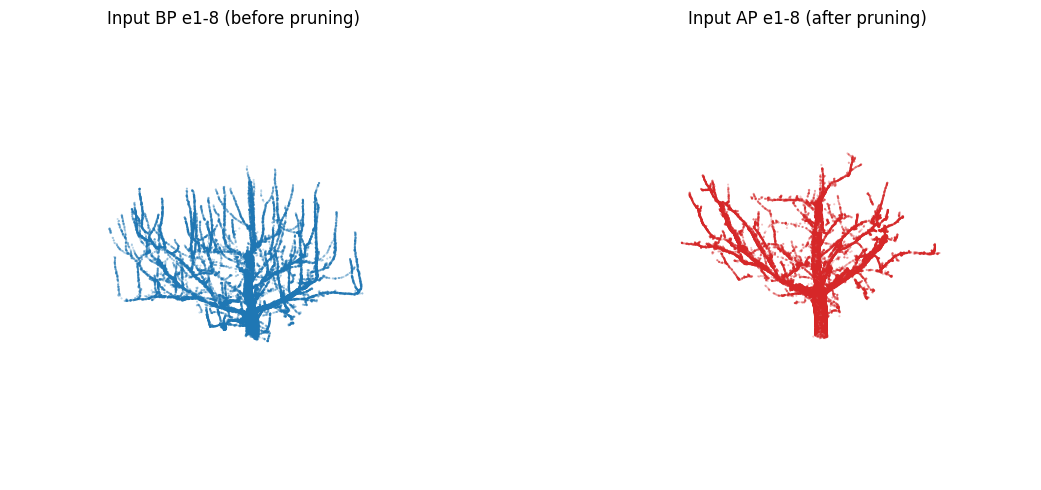

In [ ]:
import matplotlib.pyplot as plt

def plot_cloud(ax, pc, color, title, max_pts=40000):
    idx = np.random.default_rng(0).choice(len(pc), size=min(max_pts, len(pc)), replace=False)
    ax.scatter(pc[idx, 0], pc[idx, 1], pc[idx, 2], s=0.2, c=color, alpha=0.3)
    ax.set_title(title); ax.set_axis_off()

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121, projection="3d"); plot_cloud(ax1, bp, "tab:blue", "Input BP e1-8 (before pruning)")
ax2 = fig.add_subplot(122, projection="3d"); plot_cloud(ax2, ap, "tab:red",  "Input AP e1-8 (after pruning)")
plt.tight_layout(); plt.savefig("inputs_bp_ap.png", dpi=120); plt.show()

## 5. Ported author functions (pinned commit `84e65299d28d9758dff0dfed2ce6a019d724b712`)

**（EN）** Faithfully ports `sor` (statistical outlier removal, `nb_neighbors=10, std_ratio=5.0` on the raw clouds as in `Registration.align_tree`), `get_trunk` (the growing-pipe trunk extraction: 0.05 m slices, 0.8 overlap, expansion limits `maxi=0.2, mini=0.03`), and helpers from `src/Registration.py`. **One mechanical defect of the original is fixed and cited:** `align_tree` assigns `A_tree = sor(A_tree,10,5), 0.001` (an accidental tuple); the port calls `sor(...)` directly. The author's GUI calls (`show2pcd`, Open3D windows) are replaced by saved matplotlib views.

**（JA）** 著者の `Registration.py` から SOR・幹抽出（growing-pipe）等を移植します。元コードのタプル代入バグは修正し、注記しています。

In [ ]:
import open3d as o3d

def to_o3d(points):
    return o3d.geometry.PointCloud(o3d.utility.Vector3dVector(points))

def sor(points, nb_neighbors, std_ratio):
    # author Registration.sor
    pcd = to_o3d(points)
    cl, ind = pcd.remove_statistical_outlier(nb_neighbors=nb_neighbors, std_ratio=std_ratio)
    return np.asarray(pcd.select_by_index(ind).points)

def get_trunk(points, maxi, mini):
    # verbatim port of author Registration.get_trunk
    slice_thickness, overlap_ratio = 0.05, 0.8
    z_min, z_max = points[:, 2].min(), points[:, 2].max()
    z_slices = np.arange(z_min, z_max + 1e-6, slice_thickness * (1 - overlap_ratio))
    non_empty = [points[(points[:, 2] >= z) & (points[:, 2] < z + slice_thickness)]
                 for z in z_slices]
    non_empty = [s for s in non_empty if s.size > 0]
    bottom_slice = non_empty[0]
    x_range = np.ptp(bottom_slice[:, 0]); y_range = np.ptp(bottom_slice[:, 1])
    bottom_xyz = (bottom_slice[:, 0].max(), bottom_slice[:, 1].max(), bottom_slice[:, 2].min())
    max_z_keep = None
    for s in non_empty:
        dx, dy = np.ptp(s[:, 0]) - x_range, np.ptp(s[:, 1]) - y_range
        if (mini < dx < maxi) or (mini < dy < maxi):
            break
        max_z_keep = s[:, 2].max()
    filtered = points[points[:, 2] <= max_z_keep + slice_thickness] if max_z_keep is not None else bottom_slice
    return np.array(bottom_xyz), filtered

def transform_by_H(X, H):
    # verbatim port of author Registration.transform_by_H
    Xh = np.hstack([X, np.ones((X.shape[0], 1))])
    return ((H @ Xh.T).T)[:, :3] / ((H @ Xh.T).T)[:, 3][:, None]

## 6. Trunk extraction and coarse alignment

**（EN）** Applies SOR(10, 5) to both raw clouds (as in the author's `align_tree`), extracts each trunk, and coarsely aligns the BP tree to the AP tree by translating the BP trunk base to the AP trunk base (paper §2.2, Eq. 1). This runs on millions of points — the SOR steps dominate the runtime.

**（JA）** SOR ノイズ除去後、著者の手法で幹を抽出し、幹基部の一致により粗位置合わせします。

In [ ]:
print("SOR on AP..."); ap_f = sor(ap, 10, 5); print(" AP kept", len(ap_f))
print("SOR on BP..."); bp_f = sor(bp, 10, 5); print(" BP kept", len(bp_f))
ap_xyz, ap_trunk = get_trunk(ap_f, 0.2, 0.03)
bp_xyz, bp_trunk = get_trunk(bp_f, 0.2, 0.03)
print("trunk points AP/BP:", len(ap_trunk), len(bp_trunk))
t = ap_xyz - bp_xyz                     # coarse translation (author align_tree)
bp_trunk_t = sor(bp_trunk + t, 20, 3)   # author's SOR(20,3) on shifted trunks
ap_trunk_f = sor(ap_trunk, 20, 3)
print("coarse shift t =", t)

SOR on AP...


 AP kept 1438880
SOR on BP...


 BP kept 2202101


trunk points AP/BP: 133221 126103


coarse shift t = [ 5.59100008 -0.33640003 33.99720764]


## 7. Fine registration with ICP

**（EN）** Runs `SimpleICP` on the trunks with the author's parameters (`correspondences=2000, min_change=0.001, max_iterations=100`), computes the registration RMSE from the residuals, and applies the resulting 4×4 transform `H` to the **whole** coarsely shifted BP tree (author `align_tree`). The paper reports a mean whole-tree RMSE of 0.032 m; the measured value is printed from actual data.

**（JA）** 幹点群に SimpleICP（著者パラメータ）を適用し、RMSE を実測して全体点群に変換を適用します。

In [ ]:
from simpleicp import PointCloud, SimpleICP

icp = SimpleICP()
icp.add_point_clouds(PointCloud(ap_trunk_f, columns=["x", "y", "z"]),
                     PointCloud(bp_trunk_t, columns=["x", "y", "z"]))
H, bp_trunk_icp, _, residuals = icp.run(correspondences=2000, min_change=0.001, max_iterations=100)
rmse = float(np.sqrt(np.mean(np.asarray(residuals) ** 2)))
print(f"trunk ICP RMSE = {rmse:.4f} m")
bp_aligned = transform_by_H(bp_f + t, H)   # apply H to the whole BP tree
np.savetxt("/content/e1-8_BP_registered.txt", bp_aligned, fmt="%.8f")
print("registered BP:", bp_aligned.shape)

Select points for correspondences in fixed point cloud ...


Estimate normals of selected points ...


Start iterations ...


iteration | correspondences | mean(residuals) |  std(residuals)
   orig:0 |            1922 |          0.0003 |          0.0071
        1 |            1921 |         -0.0000 |          0.0062


        2 |            1906 |          0.0001 |          0.0064


...

       21 |            1920 |          0.0002 |          0.0067


       22 |            1920 |          0.0002 |          0.0067


       23 |            1920 |          0.0002 |          0.0067


Convergence criteria fulfilled -> stop iteration!
Estimated transformation matrix H:
[    0.987118     0.159963    -0.003213    -0.818813]
[   -0.159985     0.987084    -0.008410    -0.952151]
[    0.001827     0.008815     0.999959    -0.036400]
[    0.000000     0.000000     0.000000     1.000000]
... which corresponds to the following rigid-body transformation parameters:
parameter |       est.value | est.uncertainty |       obs.value |      obs.weight
   alpha1 |        0.481837 |        0.084774 |        0.000000 |       0.000e+00
   alpha2 |       -0.184120 |        0.082399 |        0.000000 |       0.000e+00
   alpha3 |       -9.204806 |        0.489241 |        0.000000 |       0.000e+00
       tx |       -0.818813 |        0.251669 |        0.000000 |       0.000e+00
       ty |       -0.952151 |        0.263466 |        0.000000 |       0.000e+00
       tz |       -0.036400 |        0.006473 |        0.000000 |       0.000e+00
(Unit of est.value, est.uncertainty, and obs.val

registered BP: (2202101, 3)


## 8. Registration check

**（EN）** Overlays the registered BP (blue) with the AP input (red). Trunks should coincide; the AS/PS differences appear at the shoots.

**（JA）** 位置合わせ後の BP（青）と AP（赤）を重ねて確認します。

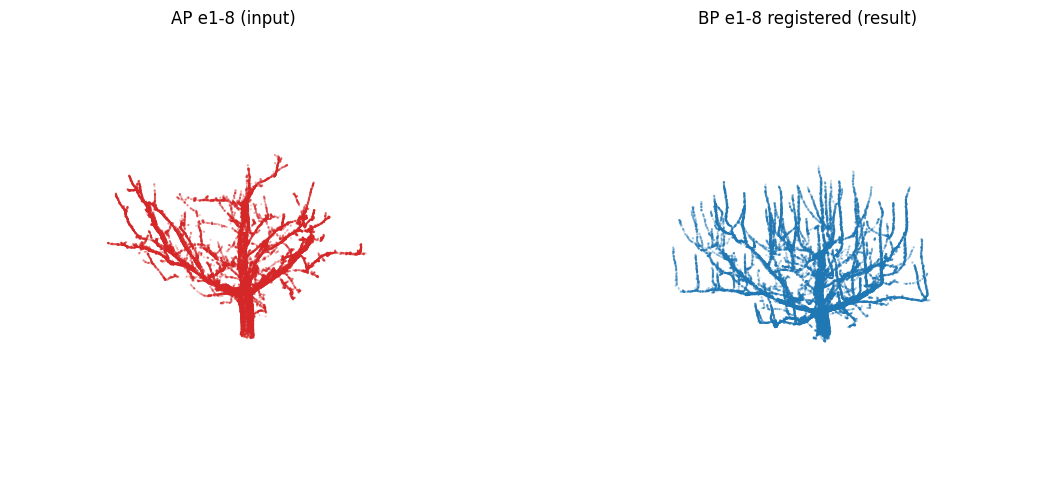

In [ ]:
fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121, projection="3d"); plot_cloud(ax1, ap_f, "tab:red", "AP e1-8 (input)")
ax2 = fig.add_subplot(122, projection="3d"); plot_cloud(ax2, bp_aligned, "tab:blue", "BP e1-8 registered (result)")
plt.tight_layout(); plt.savefig("registration_overlay.png", dpi=120); plt.show()

## 9. Annual (AS) and pruned (PS) shoot extraction

**（EN）** Per paper §2.3: after registration, points overlapping within `4 × d` are removed, where `d` is the registration RMSE; **AS** = AP points with no BP neighbor within the threshold (growth since last pruning); **PS** = BP points with no AP neighbor (material removed by pruning). This ports `filter_points_with_kdtree` with the author's `>` semantics (`src/Distancefilter&cluster.py`). *Documented fix:* `src/get_new_and_pruned.py` inverts the comparison (`<`) relative to the paper's AS/PS definitions and the sibling script; the `>` semantics is used here. The threshold uses the **measured** RMSE (the author's scripts hard-code 0.009 m for this dataset).

**（JA）** 登録 RMSE の 4 倍を閾値に、AP の非重複点を AS、BP の非重複点を PS として抽出します。

In [ ]:
from scipy.spatial import cKDTree

threshold = 4 * rmse
print(f"overlap-removal threshold = 4 x {rmse:.4f} m = {threshold:.4f} m")

def extract_nonoverlapping(reference, query, thr):
    # author filter_points_with_kdtree: keep query points whose 4 NN in reference are all > thr
    d, _ = cKDTree(reference).query(query, k=4, distance_upper_bound=thr)
    return query[np.all(d > thr, axis=1)]

as_points = extract_nonoverlapping(bp_aligned, ap_f, threshold)   # annual shoots (in AP)
ps_points = extract_nonoverlapping(ap_f, bp_aligned, threshold)   # pruned shoots (in BP)
print("AS points:", len(as_points), " PS points:", len(ps_points))

overlap-removal threshold = 4 x 0.0067 m = 0.0269 m


AS points: 866306  PS points: 1616731


## 10. Shoot clustering (DBSCAN)

**（EN）** Voxel-downsamples at 0.001 m and denoises with SOR(20, 2) as in the author's extraction scripts, then clusters each set with DBSCAN using the author's parameters (`eps = threshold`, `min_samples = 20`; `src/get_new_and_pruned.py`). Noise label −1 is dropped.

**（JA）** 0.001 m のボクセルダウンサンプルと SOR(20,2) の後、著者の DBSCAN パラメータでクラスタリングします。

In [ ]:
from sklearn.cluster import DBSCAN

def voxel_downsample(points, voxel_size):
    pcd = to_o3d(points).voxel_down_sample(voxel_size=voxel_size)
    return np.asarray(pcd.points)

def preprocess(points):
    return np.asarray(to_o3d(voxel_downsample(points, 0.001)).points)  # then SOR below

as_pre = sor(voxel_downsample(as_points, 0.001), 20, 2)
ps_pre = sor(voxel_downsample(ps_points, 0.001), 20, 2)
as_labels = DBSCAN(eps=threshold, min_samples=20).fit_predict(as_pre)
ps_labels = DBSCAN(eps=threshold, min_samples=20).fit_predict(ps_pre)
n_as = len(set(as_labels)) - (1 if -1 in as_labels else 0)
n_ps = len(set(ps_labels)) - (1 if -1 in ps_labels else 0)
print(f"AS clusters: {n_as} (from {len(as_pre)} pts)")
print(f"PS clusters: {n_ps} (from {len(ps_pre)} pts)")

AS clusters: 155 (from 770981 pts)
PS clusters: 254 (from 1437578 pts)


## 11. Shoot angle and length (OBB, author `cal_angle`)

**（EN）** For every cluster with ≥ 5 points, computes the oriented bounding box; the **angle** is between the OBB major axis and the horizontal (xy) plane in degrees, and the **length** is the OBB maximum extent (the author's active length measure in the pinned code; the skeleton-based alternative is commented out there). Results are collected in a table and exported to CSV.

**（JA）** 各クラスタの OBB から枝角度（主軸と水平面のなす角）と長さ（最大 extent）を測定し、CSV に保存します。

In [ ]:
import pandas as pd

def cal_angle(points, labels):
    # port of author parameters_measurement.cal_angle
    rows = []
    for label in sorted(set(labels)):
        if label == -1:
            continue
        pts = points[labels == label]
        if len(pts) < 5:
            continue
        obb = to_o3d(pts[:, :3]).get_oriented_bounding_box()
        main_dir = obb.R[:, 0]
        xy_proj = np.array([main_dir[0], main_dir[1], 0.0])
        cos_t = np.dot(main_dir, xy_proj) / (np.linalg.norm(main_dir) * np.linalg.norm(xy_proj))
        rows.append({"cluster": label, "angle_deg": float(np.degrees(np.arccos(cos_t))),
                     "length_m": float(max(obb.extent))})
    return pd.DataFrame(rows)

df_as = cal_angle(as_pre, as_labels); df_as["set"] = "AS (annual shoots)"
df_ps = cal_angle(ps_pre, ps_labels); df_ps["set"] = "PS (pruned shoots)"
df = pd.concat([df_as, df_ps], ignore_index=True)
display(df.describe())
df.to_csv("/content/e1-8_shoot_parameters.csv", index=False)
print(f"e1-8: {len(df_as)} AS shoots, {len(df_ps)} PS shoots measured")
print(df.groupby('set')[['angle_deg','length_m']].mean())

,cluster,angle_deg,length_m
count,409.000000,409.000000,409.000000
mean,107.740831,45.314745,0.264188
std,68.451653,24.267894,0.449365
min,0.000000,0.076433,0.005442
25%,51.000000,26.567710,0.026741
50%,102.000000,45.472632,0.072712
75%,153.000000,65.828905,0.263960
max,253.000000,88.876529,2.573399


e1-8: 155 AS shoots, 254 PS shoots measured
                    angle_deg  length_m
set                                    
AS (annual shoots)  36.433625  0.182367
PS (pruned shoots)  50.734325  0.314118


## 12. Result visualization

**（EN）** Colors every measured shoot cluster (AS in green, PS in orange) on the tree, so the extraction result can be inspected against the inputs shown above. This is the reproduction's measurement overlay on the actual sample.

**（JA）** 測定された各クラスタ（AS: 緑、PS: 橙）を樹木上に表示し、抽出結果を確認します。

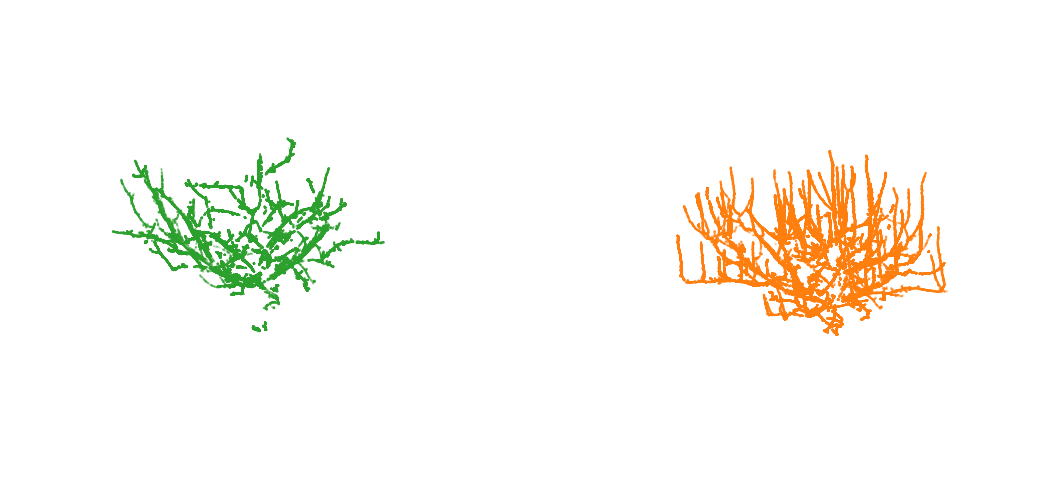

In [ ]:
fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121, projection="3d")
ax1.set_title("AS clusters (annual shoots, green)"); ax1.set_axis_off()
for label in sorted(set(as_labels)):
    if label == -1: continue
    plot_cloud(ax1, as_pre[as_labels == label], "tab:green", "", max_pts=4000)
ax2 = fig.add_subplot(122, projection="3d")
ax2.set_title("PS clusters (pruned shoots, orange)"); ax2.set_axis_off()
for label in sorted(set(ps_labels)):
    if label == -1: continue
    plot_cloud(ax2, ps_pre[ps_labels == label], "tab:orange", "", max_pts=4000)
plt.tight_layout(); plt.savefig("as_ps_clusters.png", dpi=120); plt.show()

## 13. Interpretation and limitations

**（EN）** This notebook executed the paper's registration → AS/PS extraction → clustering → OBB parameter path on the single public sample tree `e1-8` with the author's pinned parameters. It does **not** validate the paper's reported accuracies (R² 0.82/0.90/0.92/0.85 for shoot number/total length/angle/length), which required the 126-tree dataset available only on request, and it does not implement the skeleton-based length (absent from the author's active code) or the Gaussian pruning-pattern analyses. Two cited deviations: the accidental tuple assignment in `align_tree` was repaired, and the inverted kNN comparison in `get_new_and_pruned.py` was aligned with the paper §2.3 definitions and the sibling script.

**（JA）** 本ノートブックは公開サンプル 1 樹での部分再現です。論文の精度検証（126 樹データ、要請ベース）は対象外で、スケルトン長やガウス分布解析は未実装です。著者コードの 2 か所の欠陥（タプル代入、比較演算の反転）は本文書の通り修正し注記しています。

**References:** paper DOI 10.1016/j.plaphe.2025.100136; author code `Lixiao-bai/Pear_branch_seg_and_analysis` @ `84e65299d28d9758dff0dfed2ce6a019d724b712` (MIT).